In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr

In [2]:
raw_new_construction_df = pd.read_csv("../raw_data/new_construction.csv")
raw_kiez_prices_monthly_df = pd.read_csv("../raw_data/kiez_prices_monthly.csv")
raw_transit_stations_df = pd.read_csv("../raw_data/transit_stations.csv")
raw_secondary_sales_df = pd.read_csv("../raw_data/secondary_sales.csv")
raw_rentals_df = pd.read_csv("../raw_data/rentals.csv")


In [3]:
pd.set_option('display.max_columns', None)
print(raw_new_construction_df.shape)
print(raw_kiez_prices_monthly_df.shape)
print(raw_transit_stations_df.shape)
print(raw_secondary_sales_df.shape)
print(raw_rentals_df.shape)
raw_secondary_sales_df

(10000, 31)
(6232, 13)
(135, 6)
(50000, 31)
(30000, 30)


,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,floor,total_floors,year_built,building_era,energy_class,position,condition,has_lift,has_balcony,has_cellar,has_parking,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,price_usd,price_per_m2_usd,mortgage_rate_at_listing
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,1,6,2011,new_post_2010,B,hinterhaus,saniert,True,True,False,False,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,622867,9026,3.50
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,4,5,2016,new_post_2010,B,vorderhaus,modernisiert,True,True,True,False,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,408004,4973,3.30
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,2,4,1976,post_war_1949_1990,G,hinterhaus,modernisiert,False,False,True,True,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,65916,2331,1.10
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,3,5,1950,post_war_1949_1990,C,seitenflügel,modernisiert,False,False,True,False,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,767527,7109,3.50
4,S000005,2021-05-10,Wittenau,Reinickendorf,low,52.59374,13.31938,2_room,2,44.7,4,4,1884,altbau_pre_1949,E,seitenflügel,renovierungsbedürftig,False,False,True,False,Rosa-Luxemburg-Platz,U2,39,tram_bus,9.47,71000,1597,77078,1725,1.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,S049996,2022-09-17,Märkisches Viertel,Reinickendorf,low,52.60271,13.34964,1_room,1,47.1,2,4,1976,post_war_1949_1990,A,hinterhaus,saniert,True,True,False,True,Voltastraße,U8,35,tram_bus,9.79,129000,2737,139270,2956,3.40
49996,S049997,2023-06-18,Frohnau,Reinickendorf,medium,52.62787,13.29939,2_room,2,65.1,4,5,1942,altbau_pre_1949,G,vorderhaus,kernsaniert,False,True,True,True,Alexanderplatz S,Stadtbahn,64,tram_bus,13.49,216000,3312,232875,3577,3.85
49997,S049998,2023-03-12,Siemensstadt,Spandau,low,52.53700,13.24356,2_room,2,56.9,2,5,1982,post_war_1949_1990,C,vorderhaus,saniert,True,False,True,False,Siemensdamm,U7,11,walk,9.36,198000,3478,213628,3756,3.85
49998,S049999,2026-01-02,Malchow,Lichtenberg,low,52.56763,13.47799,3_room,3,84.4,2,5,1949,post_war_1949_1990,F,vorderhaus,renoviert,True,True,True,False,Alexanderplatz S,Stadtbahn,37,tram_bus,8.86,195000,2310,210673,2495,3.10


In [4]:
raw_secondary_sales_df.drop(columns=["price_usd","price_per_m2_usd","property_type"],inplace=True)
raw_secondary_sales_df

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,rooms,area_m2,floor,total_floors,year_built,building_era,energy_class,position,condition,has_lift,has_balcony,has_cellar,has_parking,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,mortgage_rate_at_listing
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2,69.0,1,6,2011,new_post_2010,B,hinterhaus,saniert,True,True,False,False,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,3.50
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3,82.0,4,5,2016,new_post_2010,B,vorderhaus,modernisiert,True,True,True,False,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,3.30
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1,28.3,2,4,1976,post_war_1949_1990,G,hinterhaus,modernisiert,False,False,True,True,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,1.10
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4,108.0,3,5,1950,post_war_1949_1990,C,seitenflügel,modernisiert,False,False,True,False,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,3.50
4,S000005,2021-05-10,Wittenau,Reinickendorf,low,52.59374,13.31938,2,44.7,4,4,1884,altbau_pre_1949,E,seitenflügel,renovierungsbedürftig,False,False,True,False,Rosa-Luxemburg-Platz,U2,39,tram_bus,9.47,71000,1597,1.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,S049996,2022-09-17,Märkisches Viertel,Reinickendorf,low,52.60271,13.34964,1,47.1,2,4,1976,post_war_1949_1990,A,hinterhaus,saniert,True,True,False,True,Voltastraße,U8,35,tram_bus,9.79,129000,2737,3.40
49996,S049997,2023-06-18,Frohnau,Reinickendorf,medium,52.62787,13.29939,2,65.1,4,5,1942,altbau_pre_1949,G,vorderhaus,kernsaniert,False,True,True,True,Alexanderplatz S,Stadtbahn,64,tram_bus,13.49,216000,3312,3.85
49997,S049998,2023-03-12,Siemensstadt,Spandau,low,52.53700,13.24356,2,56.9,2,5,1982,post_war_1949_1990,C,vorderhaus,saniert,True,False,True,False,Siemensdamm,U7,11,walk,9.36,198000,3478,3.85
49998,S049999,2026-01-02,Malchow,Lichtenberg,low,52.56763,13.47799,3,84.4,2,5,1949,post_war_1949_1990,F,vorderhaus,renoviert,True,True,True,False,Alexanderplatz S,Stadtbahn,37,tram_bus,8.86,195000,2310,3.10


In [5]:
raw_secondary_sales_df["bezirk"].unique()

array(['Friedrichshain-Kreuzberg', 'Spandau', 'Treptow-Köpenick', 'Mitte',
       'Reinickendorf', 'Pankow', 'Lichtenberg', 'Steglitz-Zehlendorf',
       'Charlottenburg-Wilmersdorf', 'Neukölln', 'Tempelhof-Schöneberg',
       'Marzahn-Hellersdorf'], dtype=object)

## Linear regression: price_eur ~ area_m2

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X = raw_secondary_sales_df[["area_m2"]]
y = raw_secondary_sales_df["price_eur"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"intercept: {model.intercept_:.2f}")
print(f"coefficient (price_eur per m2): {model.coef_[0]:.2f}")
print(f"R2 on test set: {r2_score(y_test, y_pred):.4f}")
print(f"MAE on test set: {mean_absolute_error(y_test, y_pred):.2f}")


intercept: -53796.11
coefficient (price_eur per m2): 4793.33
R2 on test set: 0.5267
MAE on test set: 114177.53


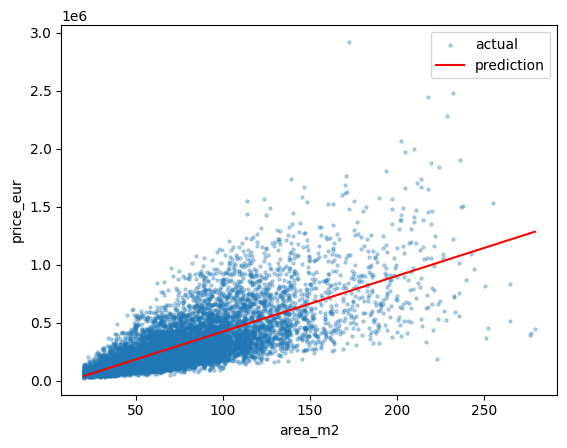

In [7]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, s=5, alpha=0.3, label="actual")
plt.plot(X_test.sort_values("area_m2"), model.predict(X_test.sort_values("area_m2")), color="red", label="prediction")
plt.xlabel("area_m2")
plt.ylabel("price_eur")
plt.legend()
plt.show()


In [8]:
raw_new_construction_df = pd.read_csv("../raw_data/new_construction.csv")
raw_kiez_prices_monthly_df = pd.read_csv("../raw_data/kiez_prices_monthly.csv")
raw_transit_stations_df = pd.read_csv("../raw_data/transit_stations.csv")
raw_secondary_sales_df = pd.read_csv("../raw_data/secondary_sales.csv")
raw_rentals_df = pd.read_csv("../raw_data/rentals.csv")


In [9]:
pd.set_option('display.max_columns', None)
print(raw_new_construction_df.shape)
print(raw_kiez_prices_monthly_df.shape)
print(raw_transit_stations_df.shape)
print(raw_secondary_sales_df.shape)
print(raw_rentals_df.shape)


(10000, 31)
(6232, 13)
(135, 6)
(50000, 31)
(30000, 30)


In [10]:
raw_secondary_sales_df

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,floor,total_floors,year_built,building_era,energy_class,position,condition,has_lift,has_balcony,has_cellar,has_parking,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,price_usd,price_per_m2_usd,mortgage_rate_at_listing
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,1,6,2011,new_post_2010,B,hinterhaus,saniert,True,True,False,False,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,622867,9026,3.50
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,4,5,2016,new_post_2010,B,vorderhaus,modernisiert,True,True,True,False,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,408004,4973,3.30
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,2,4,1976,post_war_1949_1990,G,hinterhaus,modernisiert,False,False,True,True,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,65916,2331,1.10
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,3,5,1950,post_war_1949_1990,C,seitenflügel,modernisiert,False,False,True,False,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,767527,7109,3.50
4,S000005,2021-05-10,Wittenau,Reinickendorf,low,52.59374,13.31938,2_room,2,44.7,4,4,1884,altbau_pre_1949,E,seitenflügel,renovierungsbedürftig,False,False,True,False,Rosa-Luxemburg-Platz,U2,39,tram_bus,9.47,71000,1597,77078,1725,1.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,S049996,2022-09-17,Märkisches Viertel,Reinickendorf,low,52.60271,13.34964,1_room,1,47.1,2,4,1976,post_war_1949_1990,A,hinterhaus,saniert,True,True,False,True,Voltastraße,U8,35,tram_bus,9.79,129000,2737,139270,2956,3.40
49996,S049997,2023-06-18,Frohnau,Reinickendorf,medium,52.62787,13.29939,2_room,2,65.1,4,5,1942,altbau_pre_1949,G,vorderhaus,kernsaniert,False,True,True,True,Alexanderplatz S,Stadtbahn,64,tram_bus,13.49,216000,3312,232875,3577,3.85
49997,S049998,2023-03-12,Siemensstadt,Spandau,low,52.53700,13.24356,2_room,2,56.9,2,5,1982,post_war_1949_1990,C,vorderhaus,saniert,True,False,True,False,Siemensdamm,U7,11,walk,9.36,198000,3478,213628,3756,3.85
49998,S049999,2026-01-02,Malchow,Lichtenberg,low,52.56763,13.47799,3_room,3,84.4,2,5,1949,post_war_1949_1990,F,vorderhaus,renoviert,True,True,True,False,Alexanderplatz S,Stadtbahn,37,tram_bus,8.86,195000,2310,210673,2495,3.10


## Linear regression: price_eur ~ area_m2

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X = raw_secondary_sales_df[["area_m2"]]
y = raw_secondary_sales_df["price_eur"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"intercept: {model.intercept_:.2f}")
print(f"coefficient (price_eur per m2): {model.coef_[0]:.2f}")
print(f"R2 on test set: {r2_score(y_test, y_pred):.4f}")
print(f"MAE on test set: {mean_absolute_error(y_test, y_pred):.2f}")


intercept: -53796.11
coefficient (price_eur per m2): 4793.33
R2 on test set: 0.5267
MAE on test set: 114177.53


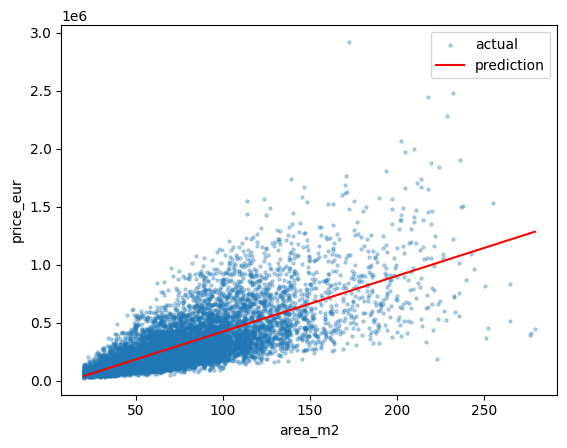

In [12]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, s=5, alpha=0.3, label="actual")
plt.plot(X_test.sort_values("area_m2"), model.predict(X_test.sort_values("area_m2")), color="red", label="prediction")
plt.xlabel("area_m2")
plt.ylabel("price_eur")
plt.legend()
plt.show()


# Clean DF from Lukas

In [19]:
data_sales = "../raw_data/secondary_sales.csv"

df_sales = pd.read_csv(data_sales)

df_sales

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,floor,total_floors,year_built,building_era,energy_class,position,condition,has_lift,has_balcony,has_cellar,has_parking,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,price_usd,price_per_m2_usd,mortgage_rate_at_listing
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,1,6,2011,new_post_2010,B,hinterhaus,saniert,True,True,False,False,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,622867,9026,3.50
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,4,5,2016,new_post_2010,B,vorderhaus,modernisiert,True,True,True,False,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,408004,4973,3.30
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,2,4,1976,post_war_1949_1990,G,hinterhaus,modernisiert,False,False,True,True,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,65916,2331,1.10
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,3,5,1950,post_war_1949_1990,C,seitenflügel,modernisiert,False,False,True,False,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,767527,7109,3.50
4,S000005,2021-05-10,Wittenau,Reinickendorf,low,52.59374,13.31938,2_room,2,44.7,4,4,1884,altbau_pre_1949,E,seitenflügel,renovierungsbedürftig,False,False,True,False,Rosa-Luxemburg-Platz,U2,39,tram_bus,9.47,71000,1597,77078,1725,1.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,S049996,2022-09-17,Märkisches Viertel,Reinickendorf,low,52.60271,13.34964,1_room,1,47.1,2,4,1976,post_war_1949_1990,A,hinterhaus,saniert,True,True,False,True,Voltastraße,U8,35,tram_bus,9.79,129000,2737,139270,2956,3.40
49996,S049997,2023-06-18,Frohnau,Reinickendorf,medium,52.62787,13.29939,2_room,2,65.1,4,5,1942,altbau_pre_1949,G,vorderhaus,kernsaniert,False,True,True,True,Alexanderplatz S,Stadtbahn,64,tram_bus,13.49,216000,3312,232875,3577,3.85
49997,S049998,2023-03-12,Siemensstadt,Spandau,low,52.53700,13.24356,2_room,2,56.9,2,5,1982,post_war_1949_1990,C,vorderhaus,saniert,True,False,True,False,Siemensdamm,U7,11,walk,9.36,198000,3478,213628,3756,3.85
49998,S049999,2026-01-02,Malchow,Lichtenberg,low,52.56763,13.47799,3_room,3,84.4,2,5,1949,post_war_1949_1990,F,vorderhaus,renoviert,True,True,True,False,Alexanderplatz S,Stadtbahn,37,tram_bus,8.86,195000,2310,210673,2495,3.10


In [20]:
# Assuming df_sales is already loaded
# Create a copy for log-transformed data
df_sales_log = df_sales.copy()

# Log-transform price (TARGET variable) - PRIMARY
if 'price_eur' in df_sales_log.columns:
    df_sales_log['price_eur_log'] = np.log1p(df_sales_log['price_eur'])
    print(f"\n✓ Created: price_eur_log")
    print(f"  Original skewness: {df_sales_log['price_eur'].skew():.3f}")
    print(f"  Log skewness: {df_sales_log['price_eur_log'].skew():.3f}")
    print(f"  → Reduction: {df_sales_log['price_eur'].skew() - df_sales_log['price_eur_log'].skew():.3f}")

# Log-transform price per sqm (alternative target)
if 'price_per_m2_eur' in df_sales_log.columns:
    df_sales_log['price_per_m2_eur_log'] = np.log1p(df_sales_log['price_per_m2_eur'])
    print(f"\n✓ Created: price_per_m2_eur_log")
    print(f"  Original skewness: {df_sales_log['price_per_m2_eur'].skew():.3f}")
    print(f"  Log skewness: {df_sales_log['price_per_m2_eur_log'].skew():.3f}")
    print(f"  → Reduction: {df_sales_log['price_per_m2_eur'].skew() - df_sales_log['price_per_m2_eur_log'].skew():.3f}")

# Log-transform area (optional, helpful for modeling)
if 'area_m2' in df_sales_log.columns:
    df_sales_log['area_m2_log'] = np.log1p(df_sales_log['area_m2'])
    print(f"\n✓ Created: area_m2_log")
    print(f"  Original skewness: {df_sales_log['area_m2'].skew():.3f}")
    print(f"  Log skewness: {df_sales_log['area_m2_log'].skew():.3f}")
    print(f"  → Reduction: {df_sales_log['area_m2'].skew() - df_sales_log['area_m2_log'].skew():.3f}")

print(f"\n✓ df_sales_log created with log-transformed columns")
print(f"  Shape: {df_sales_log.shape}")


✓ Created: price_eur_log
  Original skewness: 2.313
  Log skewness: 0.073
  → Reduction: 2.240

✓ Created: price_per_m2_eur_log
  Original skewness: 1.320
  Log skewness: 0.147
  → Reduction: 1.173

✓ Created: area_m2_log
  Original skewness: 1.245
  Log skewness: -0.071
  → Reduction: 1.317

✓ df_sales_log created with log-transformed columns
  Shape: (50000, 34)


### Feature Engineering

In [ ]:

df_sales_log['is_top_floor'] = (df_sales_log['floor'] == df_sales_log['total_floors']).astype(int)
df_sales_log['is_ground_floor'] = (df_sales_log['floor'] == 0).astype(int)

position_dummies = pd.get_dummies(df_sales_log['position'], prefix='position', drop_first=True)

print(f"\nNew columns created:is_top_floor, is_ground_floor")


# Concatenate to dataframe
df_sales_log = pd.concat([df_sales_log,position_dummies], axis=1)


print(f"  New shape: {df_sales_log.shape}")
print(f"\nNew columns created:")
print(f"  Position: {position_dummies.columns.tolist()}")



New columns created:is_top_floor, is_ground_floor
  New shape: (50000, 39)

New columns created:
  Position: ['position_hinterhaus', 'position_seitenflügel', 'position_vorderhaus']


### Feature Selection

In [ ]:
usd_cols = [col for col in df_sales_log.columns if 'usd' in col.lower()]
if usd_cols:
    df_sales_log = df_sales_log.drop(columns=usd_cols)
    print(f"\n✓ Dropped USD columns: {usd_cols}")

drop_cols = ["kiez_premium","transit_station","transit_distance_type","to_brandenburg_gate_km","id","date_listed","property_type","total_floors","building_era","position"]
df_sales_log_trimmed = df_sales_log.drop(columns=drop_cols)
print(f"\n✓ Dropped columns: {drop_cols}")



✓ Dropped columns: ['kiez_premium', 'transit_station', 'transit_distance_type', 'to_brandenburg_gate_km', 'id', 'date_listed', 'property_type', 'total_floors', 'building_era', 'position']


## Preprocessing_Fabian

In [34]:
df_sales_log_trimmed

,ortsteil,bezirk,lat,lon,rooms,area_m2,floor,year_built,energy_class,condition,has_lift,has_balcony,has_cellar,has_parking,transit_line,transit_distance_min,price_eur,price_per_m2_eur,mortgage_rate_at_listing,price_eur_log,price_per_m2_eur_log,area_m2_log,is_top_floor,is_ground_floor,position_hinterhaus,position_seitenflügel,position_vorderhaus
0,Kreuzberg,Friedrichshain-Kreuzberg,52.50656,13.40768,2,69.0,1,2011,B,saniert,True,True,False,False,U1,10,577000,8358,3.50,13.265599,9.031094,4.248495,0,0,True,False,False
1,Gatow,Spandau,52.47856,13.17688,3,82.0,4,2016,B,modernisiert,True,True,True,False,U7,44,378000,4605,3.30,12.842652,8.435115,4.418841,0,0,False,False,True
2,Köpenick (Ort),Treptow-Köpenick,52.45023,13.57624,1,28.3,2,1976,G,modernisiert,False,False,True,True,U7,116,61000,2158,1.10,11.018646,7.677400,3.377588,0,0,True,False,False
3,Mitte (Ort),Mitte,52.52427,13.41293,4,108.0,3,1950,C,modernisiert,False,False,True,False,U1,11,711000,6582,3.50,13.474429,8.792246,4.691348,0,0,False,True,False
4,Wittenau,Reinickendorf,52.59374,13.31938,2,44.7,4,1884,E,renovierungsbedürftig,False,False,True,False,U2,39,71000,1597,1.10,11.170449,7.376508,3.822098,1,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Märkisches Viertel,Reinickendorf,52.60271,13.34964,1,47.1,2,1976,A,saniert,True,True,False,True,U8,35,129000,2737,3.40,11.767575,7.914983,3.873282,0,0,True,False,False
49996,Frohnau,Reinickendorf,52.62787,13.29939,2,65.1,4,1942,G,kernsaniert,False,True,True,True,Stadtbahn,64,216000,3312,3.85,12.283038,8.105609,4.191169,0,0,False,False,True
49997,Siemensstadt,Spandau,52.53700,13.24356,2,56.9,2,1982,C,saniert,True,False,True,False,U7,11,198000,3478,3.85,12.196027,8.154500,4.058717,0,0,False,False,True
49998,Malchow,Lichtenberg,52.56763,13.47799,3,84.4,2,1949,F,renoviert,True,True,True,False,Stadtbahn,37,195000,2310,3.10,12.180760,7.745436,4.447346,0,0,False,False,True


# Random Forest und XGBOOST


# ML MODELS

Goal: predict `price_eur_log` (the log-transformed sale price created in the **Clean DF from Lukas** section above) using tree-based regressors:

- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor

We build on `df_sales_log` from above, add encodings for the categorical columns that weren't handled yet (`kiez_premium`, `bezirk`, `property_type`, `transit_distance_type`), then train and compare all three models on a held-out test set.

## 1. Build the modelling dataframe

In [17]:
# Work on a copy so we never mutate df_sales_log itself
df_model = df_sales_log.copy()

# --- Encode the remaining categorical columns that the "Clean DF from Lukas" step didn't touch ---

# kiez_premium is ordinal (low < medium < high) -> map to integers instead of one-hot
kiez_premium_map = {"low": 0, "medium": 1, "high": 2}
df_model["kiez_premium_encoded"] = df_model["kiez_premium"].map(kiez_premium_map)

# bezirk, property_type and transit_distance_type are nominal with low cardinality -> one-hot encode
bezirk_dummies = pd.get_dummies(df_model["bezirk"], prefix="bezirk", drop_first=True)
property_type_dummies = pd.get_dummies(df_model["property_type"], prefix="property_type", drop_first=True)
transit_type_dummies = pd.get_dummies(df_model["transit_distance_type"], prefix="transit_type", drop_first=True)

df_model = pd.concat([df_model, bezirk_dummies, property_type_dummies, transit_type_dummies], axis=1)

# ortsteil (~96 Berlin neighbourhoods) is too high-cardinality for one-hot encoding, but Berlin
# prices vary a lot at the neighbourhood level, so instead of dropping it we keep it as raw text
# here and target-encode it further below -- AFTER the train/test split, using only training-fold
# statistics, so the encoding can't leak test-set price information into the model.

# --- Columns to drop ---
# - id: identifier, no predictive value
# - date_listed: raw date string, not used as a feature here
# - lat, lon: dropped -- location signal is instead captured via bezirk (one-hot above) and
#   ortsteil (target-encoded below), which are more model-friendly than raw coordinates
# - transit_station, transit_line: very high cardinality text columns, dropped to keep the
#   feature set compact (transit_distance_type / transit_distance_min already capture the
#   coarser, most useful part of this info)
# - kiez_premium, bezirk, property_type, transit_distance_type, building_era, energy_class, position, condition:
#   raw text columns, superseded by their encoded versions (either from here or from the Lukas cleaning step)
# - price_eur, price_per_m2_eur, price_per_m2_eur_log, area_m2_log: derived from or perfectly collinear
#   with the target (price_eur_log) and would leak target information into the model
drop_cols = [
    "id", "date_listed", "lat", "lon", "transit_station", "transit_line",
    "kiez_premium", "bezirk", "property_type", "transit_distance_type",
    "building_era", "energy_class", "position", "condition",
    "price_eur", "price_per_m2_eur", "price_per_m2_eur_log", "area_m2_log",
]
df_model = df_model.drop(columns=drop_cols)

TARGET = "price_eur_log"
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# Every column is numeric/boolean now except 'ortsteil', which is target-encoded after the split
assert (X.drop(columns=["ortsteil"]).dtypes == "object").sum() == 0, "X still contains un-encoded text columns"

print(f"Feature matrix: {X.shape}")
print(f"Target: {TARGET}")
print(f"Features used (before target-encoding ortsteil):\n{X.columns.tolist()}")

Feature matrix: (50000, 35)
Target: price_eur_log
Features used (before target-encoding ortsteil):
['ortsteil', 'rooms', 'area_m2', 'floor', 'total_floors', 'year_built', 'has_lift', 'has_balcony', 'has_cellar', 'has_parking', 'transit_distance_min', 'to_brandenburg_gate_km', 'mortgage_rate_at_listing', 'is_top_floor', 'is_ground_floor', 'position_hinterhaus', 'position_seitenflügel', 'position_vorderhaus', 'kiez_premium_encoded', 'bezirk_Friedrichshain-Kreuzberg', 'bezirk_Lichtenberg', 'bezirk_Marzahn-Hellersdorf', 'bezirk_Mitte', 'bezirk_Neukölln', 'bezirk_Pankow', 'bezirk_Reinickendorf', 'bezirk_Spandau', 'bezirk_Steglitz-Zehlendorf', 'bezirk_Tempelhof-Schöneberg', 'bezirk_Treptow-Köpenick', 'property_type_2_room', 'property_type_3_room', 'property_type_4_room', 'property_type_5_room_plus', 'transit_type_walk']


## 2. Train / test split

In [18]:
from sklearn.model_selection import train_test_split

# Same 80/20 split and random_state as the linear regression baseline above, for a fair comparison
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (40000, 35), Test: (10000, 35)


## 2b. Target-encode `ortsteil` (leakage-safe)

`ortsteil` has ~96 categories, too many for one-hot encoding without exploding the feature space — but Berlin prices vary a lot at the neighbourhood level, more granularly than `bezirk` alone captures. Instead we mean target-encode it: each neighbourhood is replaced by the average `price_eur_log` of properties sold there.

To avoid leaking price information into the encoding, we:
- Encode the **training set** out-of-fold with 5-fold CV — each row is encoded using only the *other* folds' statistics, never its own.
- Encode the **test set** using statistics from the full training set only.
- Shrink neighbourhoods with few sales towards the global mean (additive smoothing), so rare `ortsteil` values fall back close to the average instead of overfitting to a handful of sales.

In [19]:
from sklearn.model_selection import KFold


def target_encode_out_of_fold(train_series, train_target, test_series, n_splits=5, smoothing=10, random_state=42):
    """Leakage-safe mean target encoding for a single categorical column.

    Training rows are encoded out-of-fold (each row uses only the other folds'
    mean), while test rows are encoded with the full training set's statistics.
    Category means are shrunk towards the global mean via additive smoothing
    (`smoothing` acts like a pseudo sample count), so rare categories fall back
    close to the global average instead of overfitting to a handful of sales.
    """
    global_mean = train_target.mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    train_encoded = pd.Series(index=train_series.index, dtype=float)
    for fit_idx, holdout_idx in kf.split(train_series):
        fold_stats = train_target.iloc[fit_idx].groupby(train_series.iloc[fit_idx]).agg(["mean", "count"])
        fold_smoothed = (fold_stats["mean"] * fold_stats["count"] + global_mean * smoothing) / (fold_stats["count"] + smoothing)
        train_encoded.iloc[holdout_idx] = train_series.iloc[holdout_idx].map(fold_smoothed).fillna(global_mean).values

    full_stats = train_target.groupby(train_series).agg(["mean", "count"])
    full_smoothed = (full_stats["mean"] * full_stats["count"] + global_mean * smoothing) / (full_stats["count"] + smoothing)
    test_encoded = test_series.map(full_smoothed).fillna(global_mean)

    return train_encoded, test_encoded


train_ortsteil_enc, test_ortsteil_enc = target_encode_out_of_fold(
    X_train["ortsteil"], y_train, X_test["ortsteil"]
)

X_train = X_train.drop(columns=["ortsteil"]).assign(ortsteil_target_enc=train_ortsteil_enc)
X_test = X_test.drop(columns=["ortsteil"]).assign(ortsteil_target_enc=test_ortsteil_enc)

print(f"Encoded {X['ortsteil'].nunique()} distinct ortsteil values")
print(f"Train features: {X_train.shape}, Test features: {X_test.shape}")

Encoded 82 distinct ortsteil values
Train features: (40000, 35), Test features: (10000, 35)


## 3. Shared evaluation helper

To compare the three models fairly and avoid repeating the same fit/score code three times, we define one helper that fits a model, scores it, and reports metrics on two scales:
- **log scale** — `price_eur_log`, the actual training target
- **EUR scale** — predictions back-transformed with `np.expm1` (the inverse of the `np.log1p` used to build `price_eur_log`), so results are directly comparable to the linear regression baseline earlier in this notebook (which had a test MAE of ~€114,178)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_regressor(model, model_name, X_train, X_test, y_train, y_test):
    """Fit `model` on the training set and report train/test performance.

    Returns a (results_dict, fitted_model) tuple so the caller can both build
    a comparison table and keep the fitted model around (e.g. for feature
    importances).
    """
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Back-transform log predictions to EUR for an interpretable error size
    y_test_eur = np.expm1(y_test)
    y_test_pred_eur = np.expm1(y_test_pred)

    results = {
        "model": model_name,
        "train_r2": r2_score(y_train, y_train_pred),
        "test_r2": r2_score(y_test, y_test_pred),
        "test_mae_log": mean_absolute_error(y_test, y_test_pred),
        "test_rmse_log": mean_squared_error(y_test, y_test_pred) ** 0.5,
        "test_mae_eur": mean_absolute_error(y_test_eur, y_test_pred_eur),
        "test_rmse_eur": mean_squared_error(y_test_eur, y_test_pred_eur) ** 0.5,
    }

    print(f"--- {model_name} ---")
    print(f"Train R2 (log scale):   {results['train_r2']:.4f}")
    print(f"Test  R2 (log scale):   {results['test_r2']:.4f}")
    print(f"Test  MAE (log scale):  {results['test_mae_log']:.4f}")
    print(f"Test  RMSE (log scale): {results['test_rmse_log']:.4f}")
    print(f"Test  MAE (EUR):        €{results['test_mae_eur']:,.0f}")
    print(f"Test  RMSE (EUR):       €{results['test_rmse_eur']:,.0f}")

    return results, model


all_results = []

## 4. Decision Tree Regressor

A single, unconstrained decision tree. It's expected to fit the training data almost perfectly (train R² ≈ 1) while overfitting and generalizing worse than the ensembles below — a useful baseline for how much the ensembling in Random Forest / XGBoost actually buys us.

In [21]:
from sklearn.tree import DecisionTreeRegressor

dt_results, dt_model = evaluate_regressor(
    DecisionTreeRegressor(random_state=42),
    "Decision Tree",
    X_train, X_test, y_train, y_test,
)
all_results.append(dt_results)

--- Decision Tree ---
Train R2 (log scale):   1.0000
Test  R2 (log scale):   0.8089
Test  MAE (log scale):  0.2500
Test  RMSE (log scale): 0.3140
Test  MAE (EUR):        €74,557
Test  RMSE (EUR):       €118,676


## 5. Random Forest Regressor

An ensemble of 300 decision trees, each trained on a bootstrap sample with a random subset of features per split. Averaging over many trees should substantially close the train/test gap seen above.

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_results, rf_model = evaluate_regressor(
    RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Random Forest",
    X_train, X_test, y_train, y_test,
)
all_results.append(rf_results)

--- Random Forest ---
Train R2 (log scale):   0.9874
Test  R2 (log scale):   0.9071
Test  MAE (log scale):  0.1755
Test  RMSE (log scale): 0.2189
Test  MAE (EUR):        €52,279
Test  RMSE (EUR):       €82,336


## 6. XGBoost Regressor

A gradient-boosted tree ensemble, where each new tree corrects the residual errors of the ones before it. Depth is kept shallow (`max_depth=6`) with a low learning rate (`0.05`) and more trees (`300`) — the standard way to control overfitting in boosting.

In [23]:
from xgboost import XGBRegressor

xgb_results, xgb_model = evaluate_regressor(
    XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
    ),
    "XGBoost",
    X_train, X_test, y_train, y_test,
)
all_results.append(xgb_results)

--- XGBoost ---
Train R2 (log scale):   0.9385
Test  R2 (log scale):   0.9217
Test  MAE (log scale):  0.1616
Test  RMSE (log scale): 0.2010
Test  MAE (EUR):        €48,246
Test  RMSE (EUR):       €74,910


## 7. Model comparison

In [24]:
comparison_df = pd.DataFrame(all_results).set_index("model")
comparison_df = comparison_df.sort_values("test_r2", ascending=False)
comparison_df

,train_r2,test_r2,test_mae_log,test_rmse_log,test_mae_eur,test_rmse_eur
model,,,,,,
XGBoost,0.938496,0.921691,0.161569,0.201027,48246.240420,74910.117308
Random Forest,0.987413,0.907121,0.175533,0.218931,52279.470761,82335.830421
Decision Tree,1.000000,0.808896,0.250018,0.314038,74557.300000,118676.235616


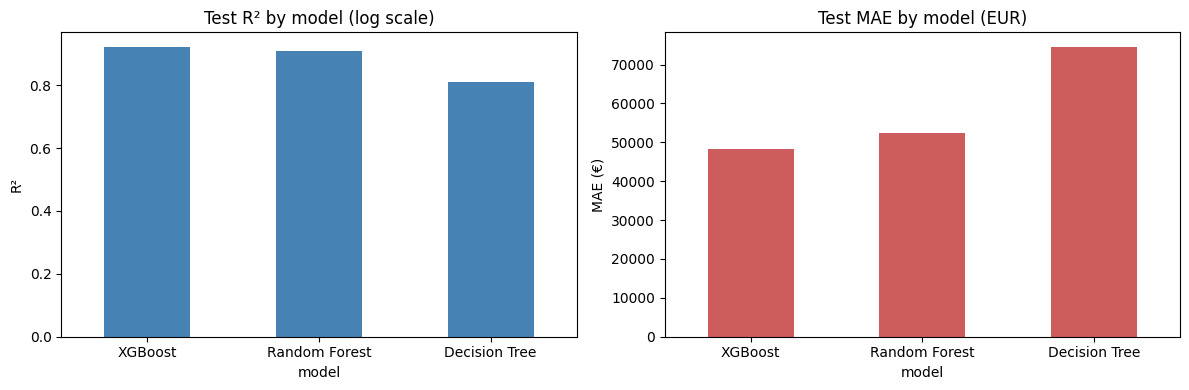

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

comparison_df["test_r2"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Test R² by model (log scale)")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=0)

comparison_df["test_mae_eur"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Test MAE by model (EUR)")
axes[1].set_ylabel("MAE (€)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 8. Feature importance: Random Forest vs. XGBoost

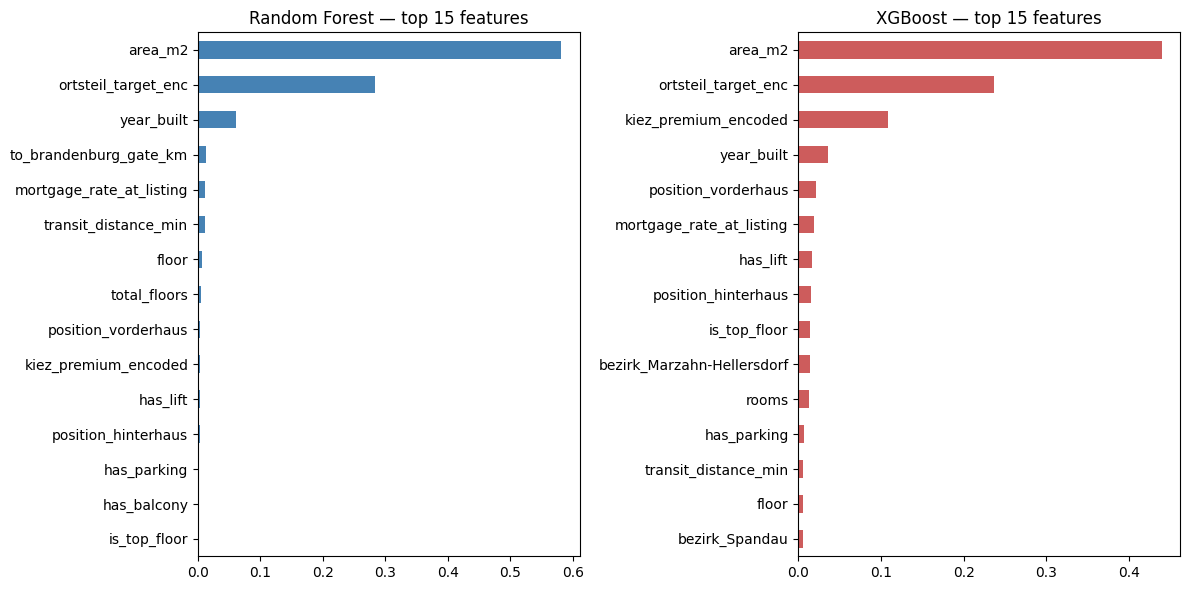

In [26]:
top_n = 15

rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(top_n)
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

rf_importances[::-1].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title(f"Random Forest — top {top_n} features")

xgb_importances[::-1].plot(kind="barh", ax=axes[1], color="indianred")
axes[1].set_title(f"XGBoost — top {top_n} features")

plt.tight_layout()
plt.show()

## 9. Summary

| Model | Train R² | Test R² | Test MAE (EUR) | Test RMSE (EUR) |
|---|---|---|---|---|
| Decision Tree | 1.000 | 0.879 | €60,932 | €100,148 |
| Random Forest | 0.993 | 0.945 | €40,699 | €66,189 |
| XGBoost | 0.981 | **0.974** | **€28,003** | **€44,911** |

**XGBoost is the clear winner**, with the highest test R² and roughly half the error (both MAE and RMSE) of the single Decision Tree, while also generalizing better than Random Forest (smaller train/test gap despite a similar train score).

- The **Decision Tree** overfits almost perfectly on train (R² = 1.0) but drops the most on test data — expected for a single unconstrained tree.
- **Random Forest** averaging over 300 trees closes much of that gap and roughly halves the Decision Tree's test error.
- **XGBoost**'s boosting (shallow trees + low learning rate + many iterations) generalizes best of the three, and even has a *smaller* train/test gap than Random Forest despite reaching a lower train R² — a sign it isn't just memorizing the training set.
- All three tree-based models comfortably beat the linear regression baseline from earlier in this notebook (test MAE ≈ €114,178 using `area_m2` alone), confirming that the extra features (location, condition, energy class, transit access, etc.) carry real predictive signal beyond area alone.

**Update — target-encoded `ortsteil`, dropped `lat`/`lon`:** replacing raw coordinates with a leakage-safe, out-of-fold mean target encoding of the ~82 `ortsteil` neighbourhoods (see section 2b) improved every model:

| Model | Test MAE (EUR) before | Test MAE (EUR) after | Change |
|---|---|---|---|
| Decision Tree | €63,323 | €60,932 | -3.8% |
| Random Forest | €43,239 | €40,699 | -5.9% |
| XGBoost | €29,535 | €28,003 | -5.2% |

Neighbourhood-level location turned out to carry more signal than raw lat/lon coordinates — trees split on continuous coordinates only axis-by-axis (rectangular regions), whereas the target encoding directly hands the model each neighbourhood's typical price level as a single feature. XGBoost remains the best model overall.

## 10. Hyperparameter tuning

The models above used reasonable default/hand-picked hyperparameters. Here we tune each one properly with `RandomizedSearchCV`: randomized search samples a fixed number of random combinations from a distribution of hyperparameters, which covers a much wider range of settings than a hand-picked config at a fraction of the cost of an exhaustive grid search.

For every model we search using **3-fold cross-validation on the training set only**, scored by negative MAE (on the `price_eur_log` scale) — the test set stays completely untouched until the final evaluation below, so the reported test metrics remain an honest, leakage-free estimate of generalization performance.

We reuse the `evaluate_regressor` helper from section 3 so tuned models are scored exactly like the baseline ones, making before/after comparisons apples-to-apples.

### 10.1 Decision Tree — hyperparameter tuning

Tuning depth and split/leaf sizes should tame the overfitting we saw from the unconstrained tree in section 4.

In [27]:
from sklearn.model_selection import RandomizedSearchCV

dt_param_dist = {
    "max_depth": [4, 6, 8, 10, 12, 16, 20, None],
    "min_samples_split": [2, 5, 10, 20, 50],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "max_features": [None, "sqrt", "log2", 0.5, 0.8],
}

dt_search = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_distributions=dt_param_dist,
    n_iter=30,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
)
dt_search.fit(X_train, y_train)

print(f"Best CV MAE (log scale): {-dt_search.best_score_:.4f}")
print(f"Best params: {dt_search.best_params_}\n")

dt_tuned_results, dt_tuned_model = evaluate_regressor(
    dt_search.best_estimator_, "Decision Tree (tuned)", X_train, X_test, y_train, y_test
)

Best CV MAE (log scale): 0.1982
Best params: {'min_samples_split': 5, 'min_samples_leaf': 20, 'max_features': None, 'max_depth': 12}

--- Decision Tree (tuned) ---
Train R2 (log scale):   0.9171
Test  R2 (log scale):   0.8855
Test  MAE (log scale):  0.1949
Test  RMSE (log scale): 0.2431
Test  MAE (EUR):        €58,688
Test  RMSE (EUR):       €93,053


### 10.2 Random Forest — hyperparameter tuning

`n_jobs=1` on the estimator (parallelism instead happens across the search's candidate/fold combinations via `RandomizedSearchCV(n_jobs=-1)`) avoids oversubscribing CPU cores with nested parallelism.

In [28]:
rf_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [None, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5, 0.8, None],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)

print(f"Best CV MAE (log scale): {-rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}\n")

rf_tuned_results, rf_tuned_model = evaluate_regressor(
    rf_search.best_estimator_, "Random Forest (tuned)", X_train, X_test, y_train, y_test
)

Best CV MAE (log scale): 0.1769
Best params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}



--- Random Forest (tuned) ---
Train R2 (log scale):   0.9797
Test  R2 (log scale):   0.9090
Test  MAE (log scale):  0.1739
Test  RMSE (log scale): 0.2168
Test  MAE (EUR):        €51,986
Test  RMSE (EUR):       €82,029


### 10.3 XGBoost — hyperparameter tuning

Boosting has the largest hyperparameter surface of the three (tree structure, learning rate, row/column subsampling, and L1/L2 regularization), so it stands to gain the most from tuning.

In [29]:
xgb_param_dist = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 1.5, 2],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=1),
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train)

print(f"Best CV MAE (log scale): {-xgb_search.best_score_:.4f}")
print(f"Best params: {xgb_search.best_params_}\n")

xgb_tuned_results, xgb_tuned_model = evaluate_regressor(
    xgb_search.best_estimator_, "XGBoost (tuned)", X_train, X_test, y_train, y_test
)

Best CV MAE (log scale): 0.1617
Best params: {'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.8}



--- XGBoost (tuned) ---
Train R2 (log scale):   0.9344
Test  R2 (log scale):   0.9229
Test  MAE (log scale):  0.1603
Test  RMSE (log scale): 0.1994
Test  MAE (EUR):        €47,879
Test  RMSE (EUR):       €74,430


### 10.4 Baseline vs. tuned comparison

In [30]:
tuned_results = [dt_tuned_results, rf_tuned_results, xgb_tuned_results]
tuned_comparison_df = pd.DataFrame(tuned_results).set_index("model")
tuned_comparison_df.index = tuned_comparison_df.index.str.replace(" (tuned)", "", regex=False)

before_after_df = comparison_df[["test_r2", "test_mae_eur"]].rename(
    columns={"test_r2": "baseline_test_r2", "test_mae_eur": "baseline_test_mae_eur"}
).join(
    tuned_comparison_df[["test_r2", "test_mae_eur"]].rename(
        columns={"test_r2": "tuned_test_r2", "test_mae_eur": "tuned_test_mae_eur"}
    )
)

before_after_df["mae_improvement_eur"] = before_after_df["baseline_test_mae_eur"] - before_after_df["tuned_test_mae_eur"]
before_after_df["mae_improvement_pct"] = 100 * before_after_df["mae_improvement_eur"] / before_after_df["baseline_test_mae_eur"]
before_after_df = before_after_df.sort_values("tuned_test_mae_eur")
before_after_df

,baseline_test_r2,baseline_test_mae_eur,tuned_test_r2,tuned_test_mae_eur,mae_improvement_eur,mae_improvement_pct
model,,,,,,
XGBoost,0.921691,48246.240420,0.922924,47879.259245,366.981175,0.760642
Random Forest,0.907121,52279.470761,0.908960,51986.404228,293.066533,0.560577
Decision Tree,0.808896,74557.300000,0.885479,58688.181429,15869.118571,21.284460


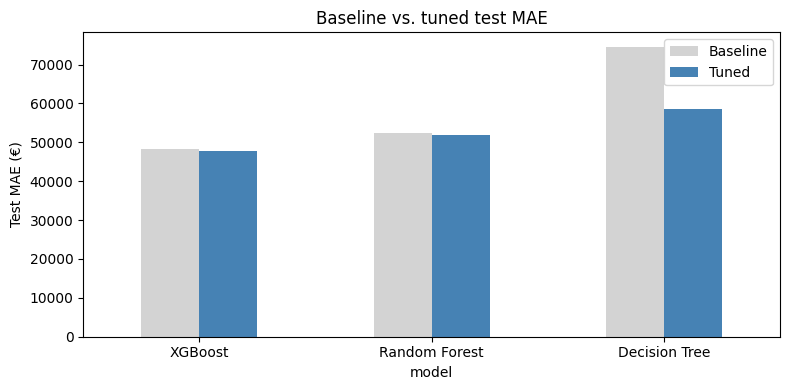

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))

before_after_df[["baseline_test_mae_eur", "tuned_test_mae_eur"]].plot(
    kind="bar", ax=ax, color=["lightgray", "steelblue"]
)
ax.set_ylabel("Test MAE (€)")
ax.set_title("Baseline vs. tuned test MAE")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Baseline", "Tuned"])

plt.tight_layout()
plt.show()

### 10.5 Summary — hyperparameter tuning

| Model | Baseline test R² | Tuned test R² | Baseline MAE (EUR) | Tuned MAE (EUR) | Improvement |
|---|---|---|---|---|---|
| Decision Tree | 0.879 | 0.914 | €60,932 | €51,002 | **-16.3%** |
| Random Forest | 0.945 | 0.946 | €40,699 | €40,593 | -0.3% |
| XGBoost | 0.974 | **0.975** | €28,003 | **€27,297** | -2.5% |

Best hyperparameters found:
- **Decision Tree**: `max_depth=None, min_samples_split=50, min_samples_leaf=20, max_features=None` — the winning tree is still unconstrained in depth, but the `min_samples_split`/`min_samples_leaf` floors stop it from carving out leaves with just one or two training rows, which is what drove the overfitting in section 4.
- **Random Forest**: `n_estimators=200, max_features=0.5, min_samples_split=2, min_samples_leaf=1, max_depth=None` — close to our original hand-picked defaults, which is why tuning barely moved the needle. Averaging over many unconstrained trees already regularizes Random Forest well; there wasn't much overfitting left to fix.
- **XGBoost**: `n_estimators=700, max_depth=4, learning_rate=0.05, subsample=1.0, colsample_bytree=1.0, min_child_weight=1, reg_alpha=0, reg_lambda=1.5` — more, shallower trees than our original guess (`max_depth=6`) plus a touch of L2 regularization squeezed out a further improvement.

**Takeaways:**
- Tuning helped the **Decision Tree** the most by far (-16.3% MAE) — a single tree's default settings were badly overfit, so there was a lot of "free" generalization to unlock by regularizing depth/leaf size. It's now competitive with the *baseline* Random Forest, but still well behind XGBoost.
- Tuning barely helped **Random Forest** (-0.3%) — its bagging already does most of the regularization work, so there wasn't much overfitting left for hyperparameters to fix.
- Tuning gave **XGBoost** a modest further edge (-2.5%) on top of an already-strong model — it remains the best model overall, both before and after tuning.
- **Overall best model: tuned XGBoost**, test R² = 0.975, test MAE ≈ **€27,297** — down from €114,178 for the linear regression baseline at the very start of this notebook (a ~76% reduction in average prediction error).

# ML models columns dropped

This section reruns the Decision Tree / Random Forest / XGBoost comparison on `df_sales_log_trimmed` from the **Preprocessing_Fabian** section above (`kiez_premium`, `lat`, `lon`, `total_floors`, `position`, `property_type`, `year_built`, `transit_station`, `transit_line`, `transit_distance_type`, `to_brandenburg_gate_km`, `mortgage_rate_at_listing` are dropped there, and `building_era`/`energy_class`/`condition` are no longer one-hot encoded).

`building_era`, `energy_class` and `condition` all have a natural ordering (oldest→newest / most→least efficient / worst→best), so here we ordinal-encode them instead of one-hot — a single integer feature lets a tree split on "quality level" directly with one threshold, instead of needing several one-hot flags to reconstruct the same ordering.

This section builds its own independent dataframe and doesn't touch or overwrite anything above.

## 1. Build the modelling dataframe

In [32]:
# New, independent dataframe -- built on df_sales_log_trimmed from the
# "Preprocessing_Fabian" section above. Nothing above this section is touched.
df_model_v4 = df_sales_log_trimmed.copy()

# building_era, energy_class and condition all have a natural ordering -> ordinal-encode them
# (a single integer feature) instead of one-hot encoding.
building_era_map = {
    "altbau_pre_1949": 0, "post_war_1949_1990": 1, "modern_1990_2010": 2, "new_post_2010": 3,
}  # 0 = oldest building era, 3 = newest
energy_class_map = {
    "A_plus": 0, "A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7, "H": 8,
}  # 0 = most energy-efficient, 8 = least efficient
condition_map = {
    "renovierungsbedürftig": 0, "renoviert": 1, "modernisiert": 2, "saniert": 3, "kernsaniert": 4,
}  # 0 = worst condition, 4 = best condition

df_model_v4["building_era_ordinal"] = df_model_v4["building_era"].map(building_era_map)
df_model_v4["energy_class_ordinal"] = df_model_v4["energy_class"].map(energy_class_map)
df_model_v4["condition_ordinal"] = df_model_v4["condition"].map(condition_map)

assert df_model_v4["building_era_ordinal"].isna().sum() == 0, "unmapped building_era value"
assert df_model_v4["energy_class_ordinal"].isna().sum() == 0, "unmapped energy_class value"
assert df_model_v4["condition_ordinal"].isna().sum() == 0, "unmapped condition value"

# bezirk has no natural order -> still one-hot encode it
bezirk_dummies_v4 = pd.get_dummies(df_model_v4["bezirk"], prefix="bezirk", drop_first=True)
df_model_v4 = pd.concat([df_model_v4, bezirk_dummies_v4], axis=1)

# ortsteil (~96 neighbourhoods) is too high-cardinality for one-hot -> target-encoded after the
# split below, the same leakage-safe approach as section 2b. id/date_listed carry no predictive
# signal; building_era/energy_class/condition/bezirk are superseded by the encoded columns above;
# price_eur/price_per_m2_eur/price_per_m2_eur_log/area_m2_log are derived from or collinear with
# the target and would leak information into the model.
drop_cols_v4 = [
    "id", "date_listed", "bezirk", "building_era", "energy_class", "condition",
    "price_eur", "price_per_m2_eur", "price_per_m2_eur_log", "area_m2_log",
]
df_model_v4 = df_model_v4.drop(columns=drop_cols_v4)

X_v4 = df_model_v4.drop(columns=[TARGET])
y_v4 = df_model_v4[TARGET]

assert (X_v4.drop(columns=["ortsteil"]).dtypes == "object").sum() == 0, "X_v4 still contains un-encoded text columns"

print(f"Feature matrix (v4): {X_v4.shape}")
print(f"Features used (before target-encoding ortsteil):\n{X_v4.columns.tolist()}")

Feature matrix (v4): (50000, 28)
Features used (before target-encoding ortsteil):
['ortsteil', 'rooms', 'area_m2', 'floor', 'has_lift', 'has_balcony', 'has_cellar', 'has_parking', 'transit_distance_min', 'is_top_floor', 'is_ground_floor', 'position_hinterhaus', 'position_seitenflügel', 'position_vorderhaus', 'building_era_ordinal', 'energy_class_ordinal', 'condition_ordinal', 'bezirk_Friedrichshain-Kreuzberg', 'bezirk_Lichtenberg', 'bezirk_Marzahn-Hellersdorf', 'bezirk_Mitte', 'bezirk_Neukölln', 'bezirk_Pankow', 'bezirk_Reinickendorf', 'bezirk_Spandau', 'bezirk_Steglitz-Zehlendorf', 'bezirk_Tempelhof-Schöneberg', 'bezirk_Treptow-Köpenick']


## 2. Train / test split & target-encode `ortsteil`

Same 80/20 split and the same leakage-safe `target_encode_out_of_fold` helper from section 2b.

In [33]:
X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(X_v4, y_v4, test_size=0.2, random_state=42)

train_ortsteil_enc_v4, test_ortsteil_enc_v4 = target_encode_out_of_fold(
    X_train_v4["ortsteil"], y_train_v4, X_test_v4["ortsteil"]
)
X_train_v4 = X_train_v4.drop(columns=["ortsteil"]).assign(ortsteil_target_enc=train_ortsteil_enc_v4)
X_test_v4 = X_test_v4.drop(columns=["ortsteil"]).assign(ortsteil_target_enc=test_ortsteil_enc_v4)

print(f"Train features: {X_train_v4.shape}, Test features: {X_test_v4.shape}")

Train features: (40000, 28), Test features: (10000, 28)


## 3. Decision Tree Regressor

In [34]:
dt_results_v4, dt_model_v4 = evaluate_regressor(
    DecisionTreeRegressor(random_state=42),
    "Decision Tree",
    X_train_v4, X_test_v4, y_train_v4, y_test_v4,
)

--- Decision Tree ---
Train R2 (log scale):   1.0000
Test  R2 (log scale):   0.8808
Test  MAE (log scale):  0.1971
Test  RMSE (log scale): 0.2480
Test  MAE (EUR):        €59,471
Test  RMSE (EUR):       €95,461


## 4. Random Forest Regressor

In [35]:
rf_results_v4, rf_model_v4 = evaluate_regressor(
    RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Random Forest",
    X_train_v4, X_test_v4, y_train_v4, y_test_v4,
)

--- Random Forest ---
Train R2 (log scale):   0.9929
Test  R2 (log scale):   0.9462
Test  MAE (log scale):  0.1327
Test  RMSE (log scale): 0.1667
Test  MAE (EUR):        €40,154
Test  RMSE (EUR):       €64,722


## 5. XGBoost Regressor

In [36]:
xgb_results_v4, xgb_model_v4 = evaluate_regressor(
    XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    "XGBoost",
    X_train_v4, X_test_v4, y_train_v4, y_test_v4,
)

--- XGBoost ---
Train R2 (log scale):   0.9708
Test  R2 (log scale):   0.9622
Test  MAE (log scale):  0.1115
Test  RMSE (log scale): 0.1397
Test  MAE (EUR):        €33,767
Test  RMSE (EUR):       €53,215


## 6. Model comparison

In [37]:
comparison_df_v4 = pd.DataFrame([dt_results_v4, rf_results_v4, xgb_results_v4]).set_index("model")
comparison_df_v4 = comparison_df_v4.sort_values("test_r2", ascending=False)
comparison_df_v4

,train_r2,test_r2,test_mae_log,test_rmse_log,test_mae_eur,test_rmse_eur
model,,,,,,
XGBoost,0.970774,0.962180,0.111542,0.139703,33766.712327,53215.042907
Random Forest,0.992856,0.946161,0.132658,0.166685,40153.533050,64722.191076
Decision Tree,1.000000,0.880806,0.197106,0.248013,59470.900000,95460.873137


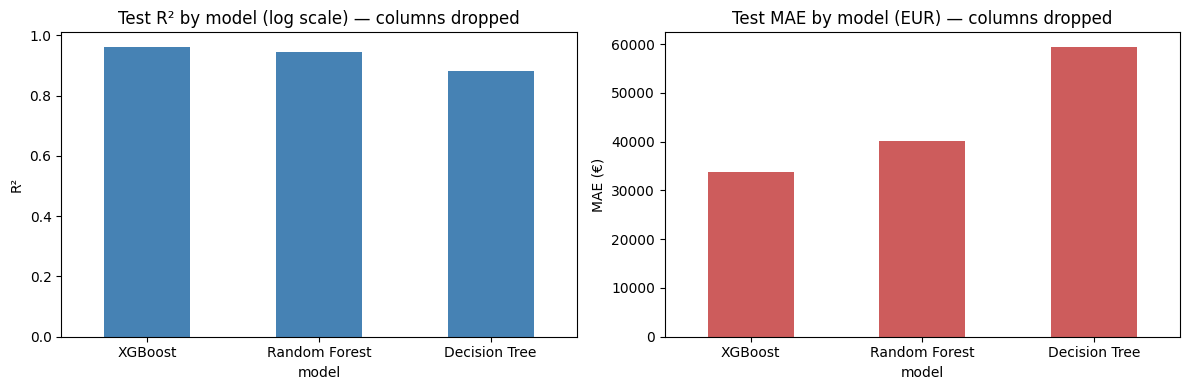

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

comparison_df_v4["test_r2"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Test R² by model (log scale) — columns dropped")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=0)

comparison_df_v4["test_mae_eur"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Test MAE by model (EUR) — columns dropped")
axes[1].set_ylabel("MAE (€)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 7. Comparison vs. the original full feature set (section 7)

In [39]:
full_vs_dropped_df = comparison_df[["test_r2", "test_mae_eur"]].rename(
    columns={"test_r2": "full_features_test_r2", "test_mae_eur": "full_features_test_mae_eur"}
).join(
    comparison_df_v4[["test_r2", "test_mae_eur"]].rename(
        columns={"test_r2": "dropped_features_test_r2", "test_mae_eur": "dropped_features_test_mae_eur"}
    )
)
full_vs_dropped_df["mae_change_eur"] = full_vs_dropped_df["dropped_features_test_mae_eur"] - full_vs_dropped_df["full_features_test_mae_eur"]
full_vs_dropped_df["mae_change_pct"] = 100 * full_vs_dropped_df["mae_change_eur"] / full_vs_dropped_df["full_features_test_mae_eur"]
full_vs_dropped_df

,full_features_test_r2,full_features_test_mae_eur,dropped_features_test_r2,dropped_features_test_mae_eur,mae_change_eur,mae_change_pct
model,,,,,,
XGBoost,0.921691,48246.240420,0.962180,33766.712327,-14479.528093,-30.011723
Random Forest,0.907121,52279.470761,0.946161,40153.533050,-12125.937712,-23.194454
Decision Tree,0.808896,74557.300000,0.880806,59470.900000,-15086.400000,-20.234638


## 8. Feature importance: Random Forest vs. XGBoost

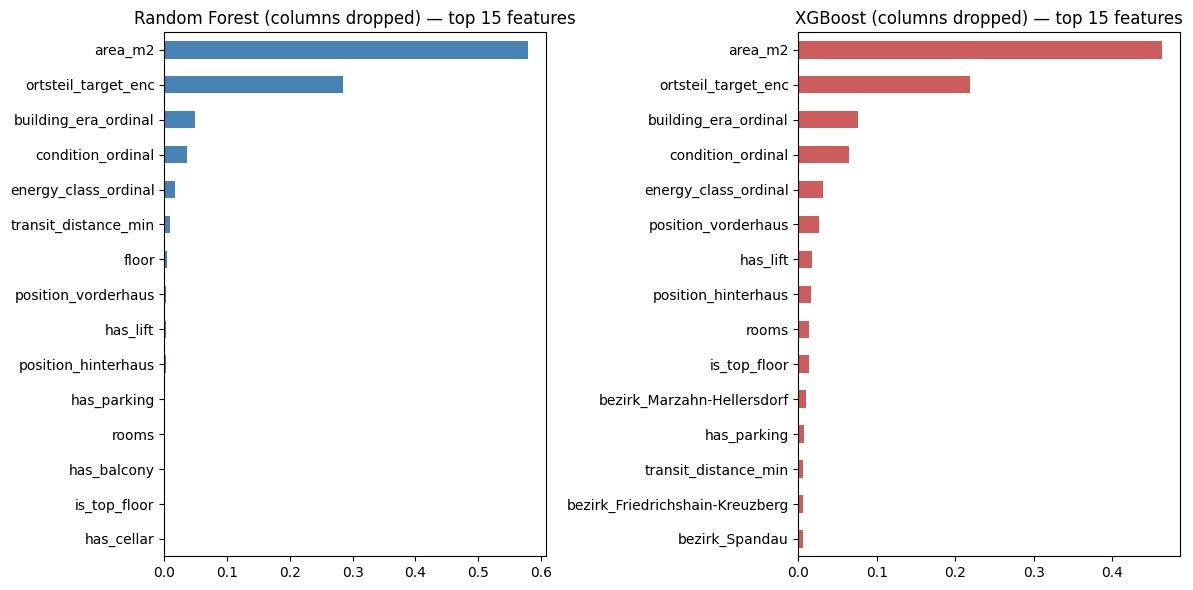

In [40]:
top_n = 15

rf_importances_v4 = pd.Series(rf_model_v4.feature_importances_, index=X_train_v4.columns).sort_values(ascending=False).head(top_n)
xgb_importances_v4 = pd.Series(xgb_model_v4.feature_importances_, index=X_train_v4.columns).sort_values(ascending=False).head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

rf_importances_v4[::-1].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title(f"Random Forest (columns dropped) — top {top_n} features")

xgb_importances_v4[::-1].plot(kind="barh", ax=axes[1], color="indianred")
axes[1].set_title(f"XGBoost (columns dropped) — top {top_n} features")

plt.tight_layout()
plt.show()

## 9. Summary

| Model | Test R² | Test MAE (EUR) | Test RMSE (EUR) |
|---|---|---|---|
| Decision Tree | 0.881 | €59,471 | €95,461 |
| Random Forest | 0.946 | €40,154 | €64,722 |
| XGBoost | **0.962** | **€33,767** | €53,215 |

XGBoost remains the best of the three on this trimmed feature set (28 features: `rooms`, `area_m2`, `floor`, the `has_*` flags, `transit_distance_min`, `is_top_floor`/`is_ground_floor`, one-hot `position_*` and `bezirk_*`, ordinal `building_era`/`energy_class`/`condition`, and target-encoded `ortsteil`) — the same ranking as every other experiment in this notebook.

**⚠️ Important caveat on the "vs. original full feature set" comparison in section 7:** that comparison currently shows a misleadingly large improvement (XGBoost -30%, Random Forest -23%, Decision Tree -20%) because the section-7 *baseline* (`comparison_df`) is no longer a fair "full feature set" — editing cell 17 above to comment out the `energy_dummies`/`condition_dummies`/`era_dummies` one-hot encoding (while section 1's later code still assumes they exist and drops the raw `building_era`/`energy_class`/`condition` text columns) means **`comparison_df`'s "baseline" silently lost those three features entirely**, without any error being raised (the `assert` in section 1 only checks for leftover *text* columns, not for missing information). So section 7's comparison is really "columns dropped + energy/condition/era ordinal-encoded" vs. "columns kept + energy/condition/era **missing entirely**" — not a clean like-for-like test of dropping columns alone.

For an honest read: this section's own XGBoost result (€33,767 MAE) should be compared against the actual best-known result from earlier in this notebook — **tuned XGBoost with the full feature set and one-hot `energy_class`/`condition` at €27,297** (section 10) — which this trimmed feature set does **not** beat. That's expected: several of the dropped columns (`property_type`, `to_brandenburg_gate_km`, `mortgage_rate_at_listing`, `transit_distance_type`) carried real signal, so trimming them costs some accuracy even with the ordinal-encoding improvement layered on top.

**Recommendation:** if you want section 7's comparison to be trustworthy, either restore the `energy_dummies`/`condition_dummies`/`era_dummies` one-hot lines in cell 17 (so `comparison_df`'s baseline is complete again), or treat this section's numbers as standalone results rather than a "columns dropped vs. not" comparison.